# Tarea 1: SGD

Somos el equipo número 5, pero estamos conformados por:
  - Raúl Llamosas Alvarado
  - Eumir Rendon Uresti
  - Gabriela Peña Franco
  - Daniela Ibarra Gatica
  - Randy Jesús García Mejía
  - Daniela Vázquez Sánchez


Las instrucciones para reproducir esta tarea por se encuentran en el [siguiente repositorio](https://github.com/MelodiousZero/tareas_modulo_7_diplomado) particularmente la parte del `README.md` que habla de los ambientes virtuales y el `requirements.txt`. 

## 1. SGD y alguna de sus variantes
### Descripción del problema

Vamos a implementar SGD y su variante AdaGrad para la pérdida cross entropy y usarlo en un problema de regresión logística con el siguiente dataset: Fashion MNIST,

### Metodología

Usaremos dos clases `LogsisticRegressionSGD` y `LogisticRegressionAdaGrad` los cuales se encuentran en `clases.py`. Para dejar el notebook limpio y sin mucho código. En ellas usaremos cross entropy loss.

### Resultados

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm
import torchvision
import torchvision.transforms as transforms
import warnings


Cargamos el conjunto de datos.


In [2]:
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

Y ahora dividimos en train y test. Además, creamos nombres para las clases (tipos de ropa)

In [3]:
X_train = train_dataset.data.numpy()  
y_train = train_dataset.targets.numpy()  

X_test = test_dataset.data.numpy()  
y_test = test_dataset.targets.numpy()  


X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0



class_names = ['Camiseta/Top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']


Y las imagenes se ven así:

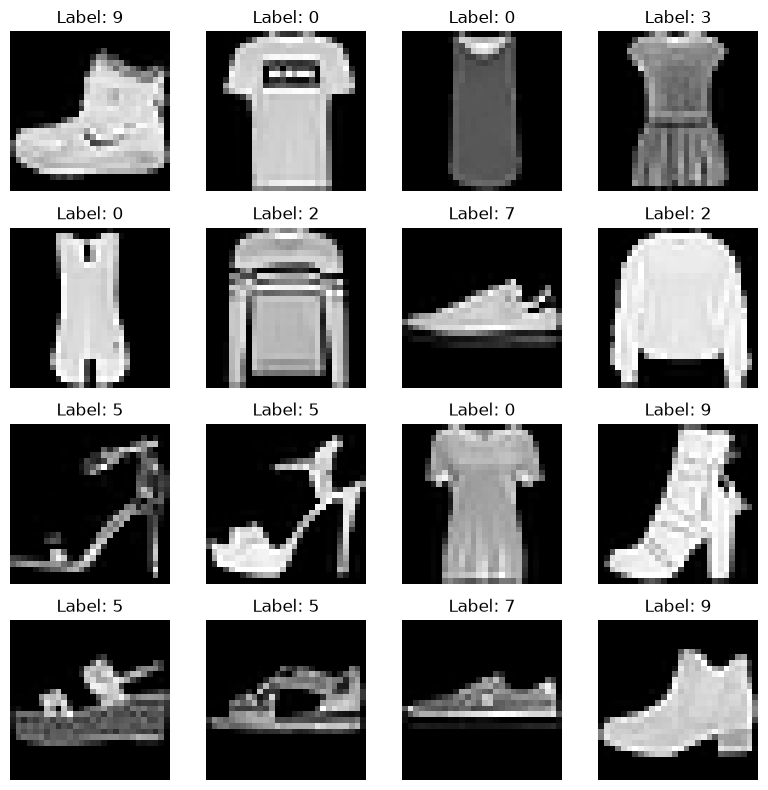

In [4]:
fig, axs = plt.subplots(4, 4, figsize=(8, 8))

for i in range(4):
    for j in range(4):
        image, label = train_dataset[i * 4 + j]  
        image_numpy = image.numpy().squeeze()    
        axs[i, j].imshow(image_numpy, cmap='gray')  
        axs[i, j].axis('off')  
        axs[i, j].set_title(f"Label: {label}") 

plt.tight_layout()  
plt.show()  

Hacemos preprocesamiento de datos, lo cual incluye escalamiento:

In [5]:

X_train_subset, X_val, y_train_subset, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print(f"Train subset: {X_train_subset.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_subset)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_bias = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_val_bias = np.c_[np.ones(X_val_scaled.shape[0]), X_val_scaled]
X_test_bias = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

print(f"\nCon bias - Train: {X_train_bias.shape}")
print(f"Con bias - Validation: {X_val_bias.shape}")
print(f"Con bias - Test: {X_test_bias.shape}")






Train subset: (54000, 784)
Validation: (6000, 784)
Test: (10000, 784)

Con bias - Train: (54000, 785)
Con bias - Validation: (6000, 785)
Con bias - Test: (10000, 785)


Y ahor así, entrenamos los modelos:

In [6]:

from clases import LogsisticRegressionSGD,LogisticRegressionAdaGrad

# Entrenar SGD
sgd_model = LogsisticRegressionSGD(learning_rate=0.01, n_iterations=500)
sgd_model.fit(X_train_bias, y_train_subset, X_val_bias, y_val)

# Entrenar AdaGrad
adagrad_model = LogisticRegressionAdaGrad(learning_rate=0.1, n_iterations=500)
adagrad_model.fit(X_train_bias, y_train_subset, X_val_bias, y_val)





Entrenando SGD...


100%|██████████| 500/500 [01:19<00:00,  6.27it/s]



Entrenando AdaGrad...


100%|██████████| 500/500 [01:18<00:00,  6.38it/s]


La evaluación de cada uno es la siguiente:

In [7]:


# Predecir con SGD
y_pred_sgd = sgd_model.predict(X_test_bias)
acc_sgd = accuracy_score(y_test, y_pred_sgd)
print(f"\nSGD - Accuracy en test: {acc_sgd:.4f}")

# Predecir con AdaGrad
y_pred_adagrad = adagrad_model.predict(X_test_bias)
acc_adagrad = accuracy_score(y_test, y_pred_adagrad)
print(f"AdaGrad - Accuracy en test: {acc_adagrad:.4f}")



SGD - Accuracy en test: 0.8173
AdaGrad - Accuracy en test: 0.8357


Por último, una visualización de datos:

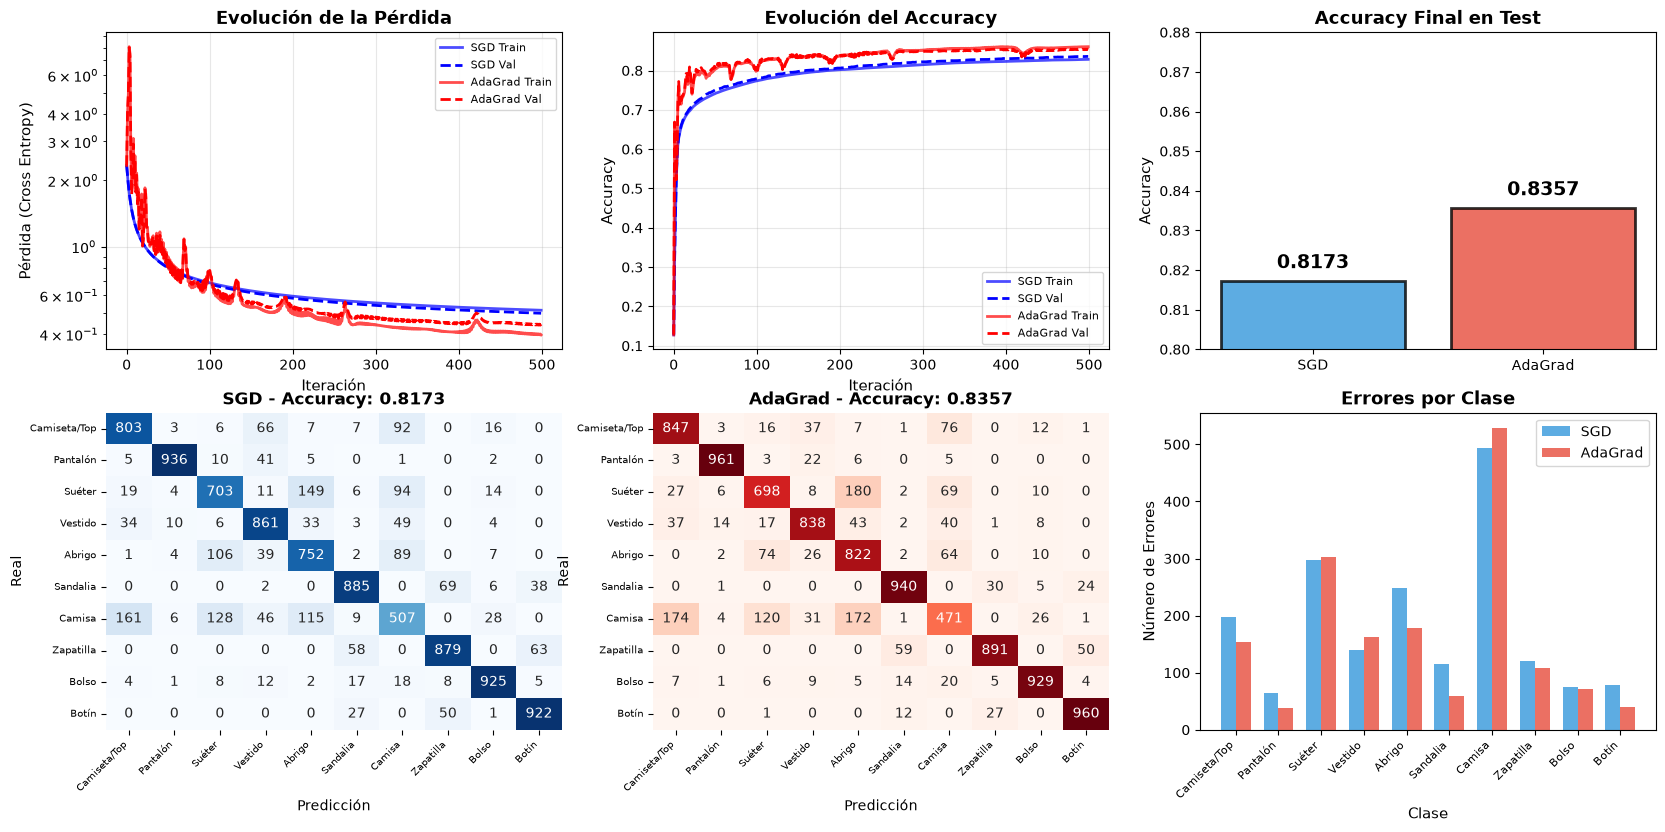

In [8]:


# Configurar figura principal
fig = plt.figure(figsize=(20, 14))

# 6.1 Evolución de la pérdida (Train + Val)
ax1 = plt.subplot(3, 3, 1)
ax1.plot(sgd_model.loss_history, label='SGD Train', linewidth=2, color='blue', alpha=0.7)
ax1.plot(sgd_model.val_loss_history, label='SGD Val', linewidth=2, color='blue', linestyle='--')
ax1.plot(adagrad_model.loss_history, label='AdaGrad Train', linewidth=2, color='red', alpha=0.7)
ax1.plot(adagrad_model.val_loss_history, label='AdaGrad Val', linewidth=2, color='red', linestyle='--')
ax1.set_xlabel('Iteración', fontsize=11)
ax1.set_ylabel('Pérdida (Cross Entropy)', fontsize=11)
ax1.set_title('Evolución de la Pérdida', fontsize=13, fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# 6.2 Evolución del accuracy (Train + Val)
ax2 = plt.subplot(3, 3, 2)
ax2.plot(sgd_model.accuracy_history, label='SGD Train', linewidth=2, color='blue', alpha=0.7)
ax2.plot(sgd_model.val_accuracy_history, label='SGD Val', linewidth=2, color='blue', linestyle='--')
ax2.plot(adagrad_model.accuracy_history, label='AdaGrad Train', linewidth=2, color='red', alpha=0.7)
ax2.plot(adagrad_model.val_accuracy_history, label='AdaGrad Val', linewidth=2, color='red', linestyle='--')
ax2.set_xlabel('Iteración', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title('Evolución del Accuracy', fontsize=13, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# 6.3 Comparación de accuracy final
ax3 = plt.subplot(3, 3, 3)
models_names = ['SGD', 'AdaGrad']
accuracies = [acc_sgd, acc_adagrad]
colors = ['#3498db', '#e74c3c']
bars = ax3.bar(models_names, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax3.set_ylabel('Accuracy', fontsize=11)
ax3.set_title('Accuracy Final en Test', fontsize=13, fontweight='bold')
ax3.set_ylim([0.80, 0.88])
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=14)

# 6.4 Matriz de confusión - SGD
ax4 = plt.subplot(3, 3, 4)
cm_sgd = confusion_matrix(y_test, y_pred_sgd)
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=class_names, yticklabels=class_names, cbar=False)
ax4.set_title(f'SGD - Accuracy: {acc_sgd:.4f}', fontsize=12, fontweight='bold')
ax4.set_xlabel('Predicción')
ax4.set_ylabel('Real')
plt.setp(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=7)
plt.setp(ax4.get_yticklabels(), rotation=0, fontsize=7)

# 6.5 Matriz de confusión - AdaGrad
ax5 = plt.subplot(3, 3, 5)
cm_adagrad = confusion_matrix(y_test, y_pred_adagrad)
sns.heatmap(cm_adagrad, annot=True, fmt='d', cmap='Reds', ax=ax5,
            xticklabels=class_names, yticklabels=class_names, cbar=False)
ax5.set_title(f'AdaGrad - Accuracy: {acc_adagrad:.4f}', fontsize=12, fontweight='bold')
ax5.set_xlabel('Predicción')
ax5.set_ylabel('Real')
plt.setp(ax5.get_xticklabels(), rotation=45, ha='right', fontsize=7)
plt.setp(ax5.get_yticklabels(), rotation=0, fontsize=7)

# 6.6 Errores por clase
ax6 = plt.subplot(3, 3, 6)
errors_sgd = np.sum(cm_sgd, axis=1) - np.diag(cm_sgd)
errors_adagrad = np.sum(cm_adagrad, axis=1) - np.diag(cm_adagrad)
x_pos = np.arange(len(class_names))
width = 0.35
ax6.bar(x_pos - width/2, errors_sgd, width, label='SGD', color='#3498db', alpha=0.8)
ax6.bar(x_pos + width/2, errors_adagrad, width, label='AdaGrad', color='#e74c3c', alpha=0.8)
ax6.set_xlabel('Clase', fontsize=11)
ax6.set_ylabel('Número de Errores', fontsize=11)
ax6.set_title('Errores por Clase', fontsize=13, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax6.legend()


### Conclusiones

Tiene sentido que AdaGrad sea mejor que SDG dado que mejora el learning rate por parametro. Así que el hecho de que sea mejor solo refleja esto. 

## 2. SGD en Scikit-learn

### Descripción del problema
Vamos a revisar la documentación de scikit-learn, la cual podemos encontrar [aquí](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDOneClassSVM.html#sklearn.linear_model.SGDOneClassSVM), para resolver algunas preguntas. En particular vamos a revisar las clases `SGDRegressor` y
`SGDClassifier`. También vamos a aplicar `SGDRegressor` en California Housing y `SGDClassifier` en Breast Cancer.
### Metodología
Contestar preguntas.
### Resultados (tablas y gráﬁcas)
a) Revisión de la documentación oficial de SGDRegressor y SGDClassifier:

- `SGDRegressor`: Implementa modelos lineales con entrenamiento SGD para regresión.
- `SGDClassifier`: Implementa clasificadores lineales (SVM, regresión logística) con SGD.

b) Explicar el papel de los siguientes elementos:

- **Función de pérdida**: Define la superficie de error (p. ej., 'squared_error', 'log_loss').

- **Tasa de aprendizaje**: Tamaño del paso ('learning_rate' e.g., 'optimal', 'adaptive').

- **Regularización**: Penalización ($L_1$, $L_2$, ElasticNet) para prevenir sobreajuste.

- **Número de épocas**: Límite máximo de iteraciones sobre todo el dataset ('max_iter').

- **Escalamiento de variables**: Crucial en SGD; evita que características con rangos grandes dominen el gradiente.

- **Criterio de parada**: Frena el entrenamiento cuando la mejora es menor a 'tol' por 'n_iter_no_change' épocas.

Ahora, vamos a aplicar `SGDRegressor` y `SGDClassifier` a sus respectivas bases de datos antes mencionadas.

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing, load_breast_cancer, load_digits
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier, SGDRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid")
np.random.seed(42)
torch.manual_seed(42)

In [10]:

# 3. Metodología y Aplicación Práctica
# c) Aplicación a bases de datos reales:
# - California Housing para SGDRegressor
# - Breast Cancer Wisconsin para SGDClassifier

# 1.- Regresión: California Housing
housing = fetch_california_housing(as_frame=True)
X_h, y_h = housing.data, housing.target

X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)
scaler_h = StandardScaler()
X_tr_h_scaled = scaler_h.fit_transform(X_tr_h)
X_te_h_scaled = scaler_h.transform(X_te_h)

sgd_reg = SGDRegressor(loss="squared_error", penalty="l2", alpha=0.0001, max_iter=1000, random_state=42)
sgd_reg.fit(X_tr_h_scaled, y_tr_h)
y_pred_sgd_reg = sgd_reg.predict(X_te_h_scaled)

ols_reg = LinearRegression()
ols_reg.fit(X_tr_h_scaled, y_tr_h)
y_pred_ols = ols_reg.predict(X_te_h_scaled)

In [11]:
# 2.- Clasificación: Breast Cancer
cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)
scaler_c = StandardScaler()
X_tr_c_scaled = scaler_c.fit_transform(X_tr_c)
X_te_c_scaled = scaler_c.transform(X_te_c)

sgd_clf = SGDClassifier(loss="log_loss", penalty="l2", max_iter=1000, random_state=42)
sgd_clf.fit(X_tr_c_scaled, y_tr_c)
y_pred_sgd_clf = sgd_clf.predict(X_te_c_scaled)

log_reg = LogisticRegression()
log_reg.fit(X_tr_c_scaled, y_tr_c)
y_pred_log = log_reg.predict(X_te_c_scaled)


Resultados:

In [12]:
# 3. Resultados
# d) Comparación con métodos de referencia:
# - Regresión Lineal Ordinaria (OLS) para California Housing
# - Regresión Logística para Breast Cancer
df_res_reg = pd.DataFrame(
    {
        "Métrica": ["MSE", "MAE", "R2"],
        "SGDRegressor": [
            mean_squared_error(y_te_h, y_pred_sgd_reg),
            mean_absolute_error(y_te_h, y_pred_sgd_reg),
            r2_score(y_te_h, y_pred_sgd_reg),
        ],
        "OLS Baseline": [
            mean_squared_error(y_te_h, y_pred_ols),
            mean_absolute_error(y_te_h, y_pred_ols),
            r2_score(y_te_h, y_pred_ols),
        ],
    }
)

df_res_clf = pd.DataFrame(
    {
        "Modelo": ["SGDClassifier (LogLoss)", "LogisticRegression"],
        "Accuracy": [
            accuracy_score(y_te_c, y_pred_sgd_clf),
            accuracy_score(y_te_c, y_pred_log),
        ],
    }
)

print("Ejercicio 2: Comparativa Regresión")
print(df_res_reg.to_string(index=False))
print("Ejercicio 2: Comparativa Clasificación")
print(df_res_clf.to_string(index=False))

Ejercicio 2: Comparativa Regresión
Métrica  SGDRegressor  OLS Baseline
    MSE      0.550599      0.555892
    MAE      0.529883      0.533200
     R2      0.579827      0.575788
Ejercicio 2: Comparativa Clasificación
                 Modelo  Accuracy
SGDClassifier (LogLoss)  0.964912
     LogisticRegression  0.973684


### Conclusiones
SGDRegressor y SGDClassifier logran un rendimiento casi idéntico a los modelos exactos (OLS y Regresión Logística), ofreciendo mayor eficiencia computacional en grandes volúmenes de datos.

## 3. SGD y sus variantes en redes neuronales

### Descripción del problema

Queremos resolver un problema de **regresión con datos reales** usando una **red neuronal multicapa (MLP)** y comparar el comportamiento de diferentes optimizadores durante el entrenamiento de **una misma arquitectura**.

Usamos la base de datos **California Housing** (la misma que empleamos en el Ejercicio 2), que contiene 8 covariables por distrito censal de California (ingreso mediano, edad mediana de las viviendas, promedio de cuartos, promedio de recámaras, población, ocupación promedio, latitud y longitud) y como variable respuesta el **valor mediano de la vivienda** (en unidades de \$100,000 USD). El objetivo es predecir dicho valor a partir de las covariables.

Manteniendo fija la arquitectura de la red, la inicialización de los pesos y el tamaño de minilote, entrenamos con seis optimizadores distintos:

1. **SGD** clásico
2. **SGD con momentum**
3. **AdaGrad**
4. **RMSProp**
5. **Adam**
6. **AdamW**

y comparamos su velocidad de convergencia, su error final en validación y prueba (MSE, MAE, RMSE y $R^2$), la presencia de sobreajuste y su sensibilidad a la tasa de aprendizaje.

### Metodología

1. **Exploración de la base de datos**: estadísticas descriptivas y distribución de la variable respuesta.
2. **Partición de los datos** en entrenamiento (60%), validación (20%) y prueba (20%).
3. **Estandarización** de las variables explicativas con `StandardScaler`, ajustado *únicamente* con el conjunto de entrenamiento para evitar fuga de información.
4. **Arquitectura fija**: red multicapa sencilla $8 \to 64 \to 32 \to 1$ con activaciones ReLU en las capas ocultas y salida lineal, entrenada con pérdida **MSE**. Implementamos la red y la retropropagación **desde cero con NumPy** (igual que en el Ejercicio 1), y verificamos numéricamente el gradiente.
5. **Optimizadores implementados desde cero**, todos con la misma inicialización (misma semilla) y minilotes de 256 observaciones. Con $g_n = \nabla \ell(\theta_n)$ el gradiente del minilote:

   * **SGD**: $\theta_{n+1} = \theta_n - \eta\, g_n$
   * **SGD con momentum**: $v_{n+1} = \beta v_n + g_n$, $\quad \theta_{n+1} = \theta_n - \eta\, v_{n+1}$
   * **AdaGrad**: $G_{n+1} = G_n + g_n^2$, $\quad \theta_{n+1} = \theta_n - \dfrac{\eta}{\sqrt{G_{n+1}} + \epsilon}\, g_n$
   * **RMSProp**: $G_{n+1} = \rho G_n + (1-\rho) g_n^2$, $\quad \theta_{n+1} = \theta_n - \dfrac{\eta}{\sqrt{G_{n+1}} + \epsilon}\, g_n$
   * **Adam**: $m_{n+1} = \rho_1 m_n + (1-\rho_1) g_n$, $\; v_{n+1} = \rho_2 v_n + (1-\rho_2) g_n^2$, con corrección de sesgo $\hat m = m_{n+1}/(1-\rho_1^{n+1})$, $\hat v = v_{n+1}/(1-\rho_2^{n+1})$ y $\theta_{n+1} = \theta_n - \eta\, \hat m / (\sqrt{\hat v} + \epsilon)$
   * **AdamW**: igual que Adam pero con *weight decay* desacoplado: $\theta_{n+1} = \theta_n - \eta\, \big(\hat m / (\sqrt{\hat v} + \epsilon) + \lambda\, \theta_n\big)$

   Las tasas de aprendizaje se eligieron del orden típico para cada método ($\eta = 0.01$ para SGD y momentum, $0.05$ para AdaGrad, $0.005$ para RMSProp, Adam y AdamW).
6. **Registro por época** de la pérdida (MSE) en entrenamiento y validación para cada optimizador.
7. **Evaluación final** en el conjunto de prueba con MSE, MAE, RMSE y $R^2$, comparando además contra una **regresión lineal ordinaria** como referencia (conectando con el Ejercicio 2).
8. **Experimento de sensibilidad**: reentrenamos SGD y Adam con $\eta \in \{0.1,\ 0.01,\ 0.001\}$ para estudiar el efecto de la tasa de aprendizaje.
### Resultados (tablas y gráﬁcas)
A continuación los resultados


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEMILLA = 42
np.random.seed(SEMILLA)

### a) Exploración de la base de datos

Cargamos **California Housing**. Usamos `fetch_california_housing` de scikit-learn; si la descarga fallara (p. ej. sin acceso a figshare), reconstruimos exactamente las mismas 8 covariables a partir de una copia pública del archivo original de StatLib.

In [14]:
def cargar_california_housing():
    try:
        from sklearn.datasets import fetch_california_housing
        datos = fetch_california_housing()
        X = pd.DataFrame(datos.data, columns=datos.feature_names)
        y = pd.Series(datos.target, name='MedHouseVal')
        print('Datos cargados con fetch_california_housing (scikit-learn).')
    except Exception as e:
        # Respaldo: copia pública del dataset original; construimos las mismas variables
        # que scikit-learn (se descartan 207 renglones con faltantes en total_bedrooms).
        print('fetch_california_housing falló, usando respaldo de GitHub...')
        url = 'https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv'
        df = pd.read_csv(url).dropna()
        X = pd.DataFrame({
            'MedInc': df['median_income'],
            'HouseAge': df['housing_median_age'],
            'AveRooms': df['total_rooms'] / df['households'],
            'AveBedrms': df['total_bedrooms'] / df['households'],
            'Population': df['population'],
            'AveOccup': df['population'] / df['households'],
            'Latitude': df['latitude'],
            'Longitude': df['longitude'],
        }).reset_index(drop=True)
        y = pd.Series(df['median_house_value'].values / 100000.0, name='MedHouseVal')
    return X, y

X_df, y_s = cargar_california_housing()
print('Dimensiones:', X_df.shape, y_s.shape)
X_df.describe().T.round(3)

Datos cargados con fetch_california_housing (scikit-learn).
Dimensiones: (20640, 8) (20640,)


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.871,1.900,0.500,2.563,3.535,4.743,15.000
HouseAge,20640.0,28.639,12.586,1.000,18.000,29.000,37.000,52.000
AveRooms,20640.0,5.429,2.474,0.846,4.441,5.229,6.052,141.909
AveBedrms,20640.0,1.097,0.474,0.333,1.006,1.049,1.100,34.067
Population,20640.0,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
AveOccup,20640.0,3.071,10.386,0.692,2.430,2.818,3.282,1243.333
Latitude,20640.0,35.632,2.136,32.540,33.930,34.260,37.710,41.950
Longitude,20640.0,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310


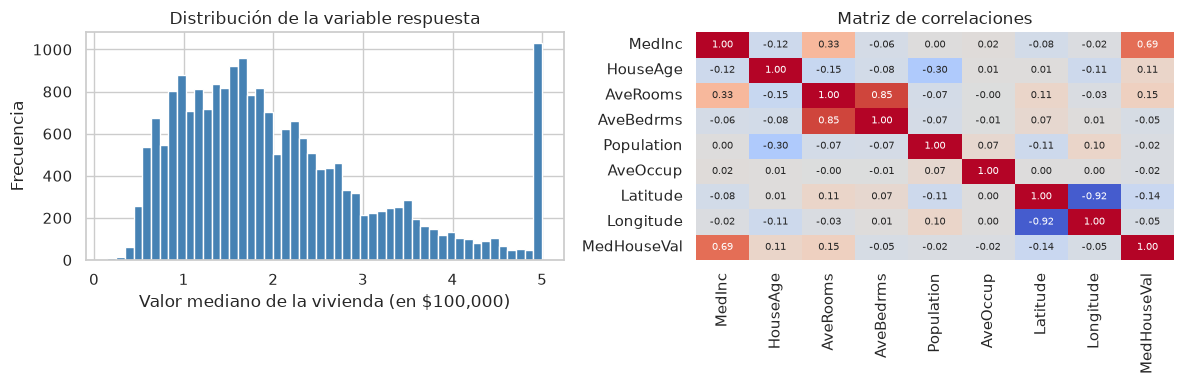

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(y_s, bins=50, color='steelblue', edgecolor='white')
axs[0].set_xlabel('Valor mediano de la vivienda (en $100,000)')
axs[0].set_ylabel('Frecuencia')
axs[0].set_title('Distribución de la variable respuesta')

corr = pd.concat([X_df, y_s], axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axs[1], annot_kws={'size': 7}, cbar=False)
axs[1].set_title('Matriz de correlaciones')
plt.tight_layout()
plt.show()

**Observaciones**: la variable respuesta está acotada en $[0.15, 5]$ (los valores mayores a \$500,000 fueron censurados en el levantamiento original, lo que produce el pico en 5). La covariable más correlacionada con el precio es el ingreso mediano (`MedInc`). Las escalas de las covariables son muy distintas (p. ej. `Population` vs. `Latitude`), por lo que la **estandarización es indispensable** para que el descenso de gradiente funcione bien.

### b) y c) Partición entrenamiento/validación/prueba y estandarización

In [16]:
X = X_df.to_numpy()
y = y_s.to_numpy()

# 60% entrenamiento, 20% validación, 20% prueba
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.4, random_state=SEMILLA)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=SEMILLA)

# Estandarizamos SOLO con estadísticas del conjunto de entrenamiento
escalador = StandardScaler()
X_train = escalador.fit_transform(X_train)
X_val = escalador.transform(X_val)
X_test = escalador.transform(X_test)

print(f'Entrenamiento: {X_train.shape[0]} | Validación: {X_val.shape[0]} | Prueba: {X_test.shape[0]}')

Entrenamiento: 12384 | Validación: 4128 | Prueba: 4128


### d) Red neuronal multicapa

Implementamos una MLP $8 \to 64 \to 32 \to 1$ con ReLU y salida lineal. La clase calcula el paso hacia adelante y la retropropagación del gradiente de la pérdida MSE
$$\ell(\theta) = \frac{1}{m}\sum_{i=1}^{m} (\hat y_i - y_i)^2,$$
respecto de todos los pesos y sesgos. Usamos inicialización de He (adecuada para ReLU) con semilla fija, de modo que **todos los optimizadores parten exactamente de los mismos pesos iniciales**.

In [17]:
from clases import MLP

**Verificación numérica del gradiente.** Antes de entrenar, comprobamos que la retropropagación está bien implementada comparando contra diferencias finitas centradas: $\partial \ell / \partial \theta_j \approx \big(\ell(\theta + \epsilon e_j) - \ell(\theta - \epsilon e_j)\big) / 2\epsilon$. Un error relativo del orden de $10^{-7}$ o menor indica que el gradiente analítico es correcto.

In [18]:
def verificar_gradiente(epsilon=1e-6):
    rng = np.random.default_rng(0)
    red = MLP(5, n_oculta1=8, n_oculta2=6, semilla=0)
    # ReLU no es diferenciable en 0; desplazamos los sesgos para evaluar el
    # gradiente en un punto alejado de los quiebres y evitar falsos errores.
    red.params['b1'] += 0.1
    red.params['b2'] += 0.1
    X_chico = rng.normal(size=(12, 5))
    y_chico = rng.normal(size=12)
    red.forward(X_chico)
    grads = red.backward(y_chico)
    errores = {}
    for clave in red.params:
        numerico = np.zeros_like(red.params[clave])
        it = np.nditer(red.params[clave], flags=['multi_index'])
        for _ in it:
            idx = it.multi_index
            red.params[clave][idx] += epsilon
            perdida_mas = red.perdida(X_chico, y_chico)
            red.params[clave][idx] -= 2 * epsilon
            perdida_menos = red.perdida(X_chico, y_chico)
            red.params[clave][idx] += epsilon
            numerico[idx] = (perdida_mas - perdida_menos) / (2 * epsilon)
        errores[clave] = np.max(np.abs(numerico - grads[clave]) /
                                (np.abs(numerico) + np.abs(grads[clave]) + 1e-12))
    for clave, err in errores.items():
        print(f'  {clave}: error relativo máximo = {err:.2e}')

verificar_gradiente()

  W1: error relativo máximo = 9.70e-07
  b1: error relativo máximo = 1.14e-09
  W2: error relativo máximo = 7.50e-09
  b2: error relativo máximo = 1.18e-09
  W3: error relativo máximo = 1.71e-08
  b3: error relativo máximo = 1.40e-10


### e) Optimizadores

Cada optimizador se implementa como una clase con un método `update(params, grads)` que aplica su regla de actualización (ver Metodología). Así garantizamos que lo **único** que cambia entre corridas es el optimizador.

In [19]:
from clases import SGD, SGDMomentum, AdaGrad, RMSProp,Adam,AdamW

In [20]:
def entrenar(red, optimizador, X_train, y_train, X_val, y_val,
             epocas=100, tam_lote=256, semilla=SEMILLA):
    """Entrena la red con minilotes y registra la pérdida (MSE) por época."""
    rng = np.random.default_rng(semilla)
    n = X_train.shape[0]
    hist_train, hist_val = [], []
    for _ in range(epocas):
        indices = rng.permutation(n)
        for i in range(0, n, tam_lote):
            lote = indices[i:i + tam_lote]
            red.forward(X_train[lote])
            grads = red.backward(y_train[lote])
            optimizador.update(red.params, grads)
        hist_train.append(red.perdida(X_train, y_train))
        hist_val.append(red.perdida(X_val, y_val))
    return hist_train, hist_val

In [21]:
EPOCAS = 100

optimizadores = {
    'SGD':            lambda: SGD(lr=0.01),
    'SGD + Momentum': lambda: SGDMomentum(lr=0.01, beta=0.9),
    'AdaGrad':        lambda: AdaGrad(lr=0.05),
    'RMSProp':        lambda: RMSProp(lr=0.005),
    'Adam':           lambda: Adam(lr=0.005),
    'AdamW':          lambda: AdamW(lr=0.005, wd=1e-4),
}

historiales = {}
modelos = {}
for nombre, crear_opt in optimizadores.items():
    red = MLP(X_train.shape[1], semilla=SEMILLA)
    hist_train, hist_val = entrenar(red, crear_opt(), X_train, y_train, X_val, y_val, epocas=EPOCAS)
    historiales[nombre] = (hist_train, hist_val)
    modelos[nombre] = red
    print(f'{nombre:15s} | MSE entrenamiento: {hist_train[-1]:.4f} | MSE validación: {hist_val[-1]:.4f}')

SGD             | MSE entrenamiento: 0.3239 | MSE validación: 0.3635
SGD + Momentum  | MSE entrenamiento: 0.2508 | MSE validación: 0.3030
AdaGrad         | MSE entrenamiento: 0.2590 | MSE validación: 0.3054
RMSProp         | MSE entrenamiento: 0.2201 | MSE validación: 0.3011
Adam            | MSE entrenamiento: 0.2139 | MSE validación: 0.2844
AdamW           | MSE entrenamiento: 0.2182 | MSE validación: 0.2913


### Resultados finales
#### g) Curvas de pérdida en entrenamiento y validación


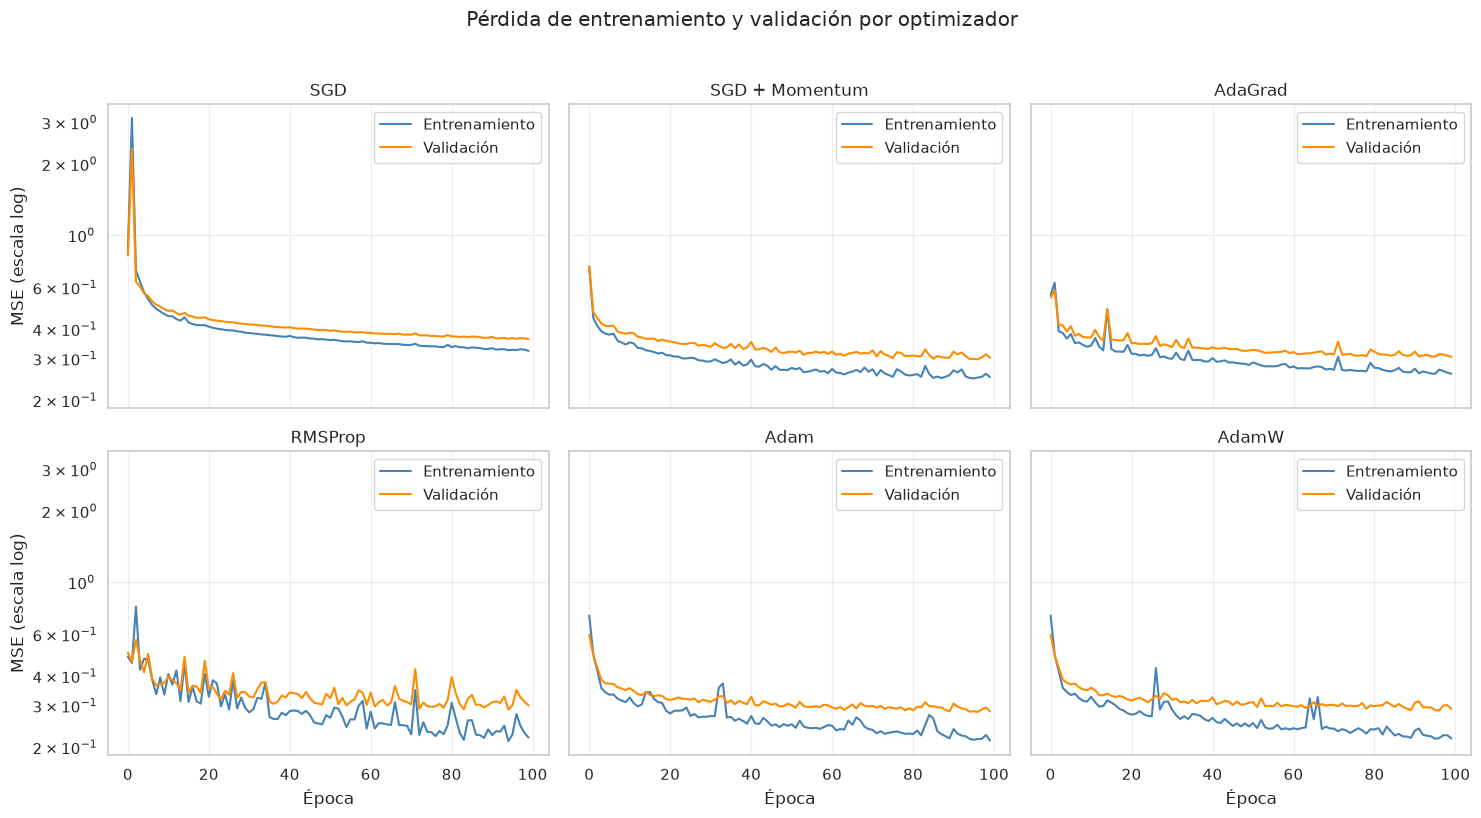

In [22]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for ax, (nombre, (hist_train, hist_val)) in zip(axs.ravel(), historiales.items()):
    ax.plot(hist_train, label='Entrenamiento', color='steelblue')
    ax.plot(hist_val, label='Validación', color='darkorange')
    ax.set_title(nombre)
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.legend()
for ax in axs[1]:
    ax.set_xlabel('Época')
for ax in axs[:, 0]:
    ax.set_ylabel('MSE (escala log)')
plt.suptitle('Pérdida de entrenamiento y validación por optimizador', y=1.02)
plt.tight_layout()
plt.show()

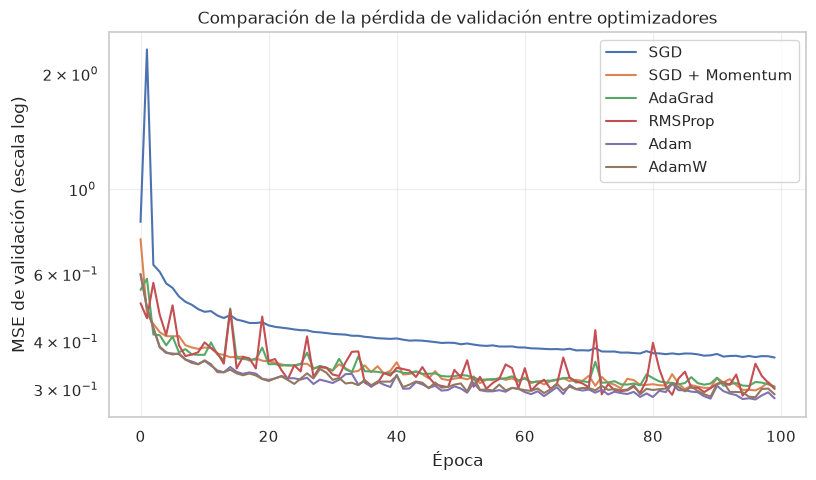

In [23]:
plt.figure(figsize=(9, 5))
for nombre, (hist_train, hist_val) in historiales.items():
    plt.plot(hist_val, label=nombre)
plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('MSE de validación (escala log)')
plt.title('Comparación de la pérdida de validación entre optimizadores')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### f) Métricas de regresión en el conjunto de prueba

Evaluamos cada modelo entrenado en el conjunto de **prueba** (datos nunca vistos durante el entrenamiento ni la selección) y comparamos contra una **regresión lineal ordinaria** como método de referencia, tal como hicimos en el Ejercicio 2.

In [24]:
# Método de referencia: regresión lineal ordinaria (OLS)
ols = LinearRegression().fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)

filas = []
for nombre, red in modelos.items():
    y_pred = red.forward(X_test)
    filas.append({
        'Optimizador': nombre,
        'MSE': mean_squared_error(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
    })
filas.append({
    'Optimizador': 'Regresión lineal (referencia)',
    'MSE': mean_squared_error(y_test, y_pred_ols),
    'MAE': mean_absolute_error(y_test, y_pred_ols),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ols)),
    'R2': r2_score(y_test, y_pred_ols),
})

tabla = pd.DataFrame(filas).set_index('Optimizador').sort_values('MSE')
tabla.round(4)

,MSE,MAE,RMSE,R2
Optimizador,,,,
AdamW,0.2774,0.3548,0.5266,0.7977
Adam,0.2778,0.3566,0.5271,0.7974
SGD + Momentum,0.2830,0.3691,0.5319,0.7936
AdaGrad,0.2894,0.3697,0.5380,0.7889
RMSProp,0.2974,0.3651,0.5453,0.7831
SGD,0.3493,0.4171,0.5910,0.7453
Regresión lineal (referencia),0.5546,0.5338,0.7447,0.5955


### Sensibilidad a la tasa de aprendizaje

Para responder la pregunta d), reentrenamos (con menos épocas) los dos extremos del espectro —**SGD clásico** y **Adam**— usando la misma malla de tasas $\eta \in \{0.1,\ 0.01,\ 0.001\}$.

SGD con lr=0.1: MSE de validación final = 0.3275
SGD con lr=0.01: MSE de validación final = 0.4066
SGD con lr=0.001: MSE de validación final = 0.5881
Adam con lr=0.1: MSE de validación final = 0.3381
Adam con lr=0.01: MSE de validación final = 0.2907
Adam con lr=0.001: MSE de validación final = 0.3452


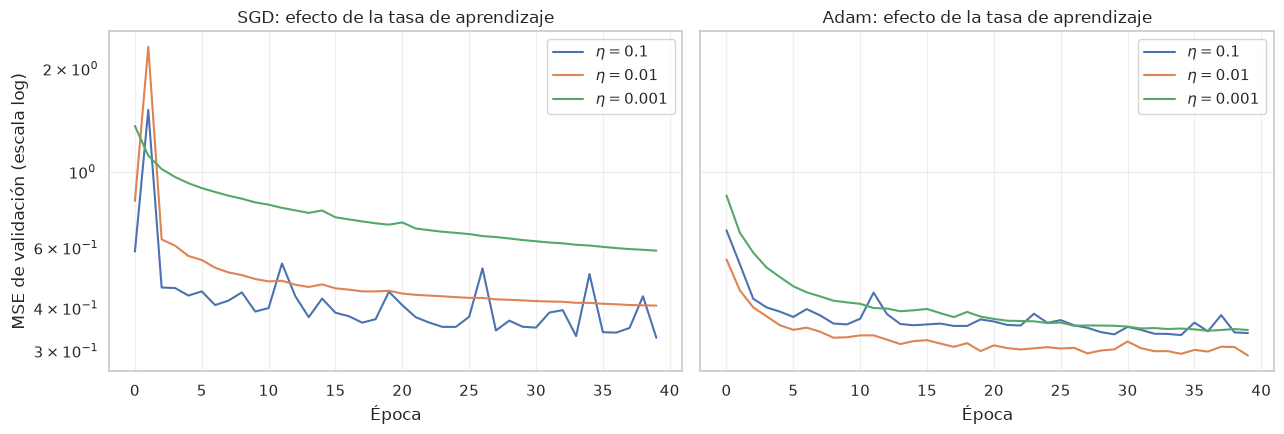

In [25]:
tasas = [0.1, 0.01, 0.001]
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (nombre, clase) in zip(axs, [('SGD', SGD), ('Adam', Adam)]):
    for lr in tasas:
        red = MLP(X_train.shape[1], semilla=SEMILLA)
        _, hist_val = entrenar(red, clase(lr=lr), X_train, y_train,
                               X_val, y_val, epocas=40)
        ax.plot(hist_val, label=fr'$\eta = {lr}$')
        print(f'{nombre} con lr={lr}: MSE de validación final = {hist_val[-1]:.4f}')
    ax.set_title(f'{nombre}: efecto de la tasa de aprendizaje')
    ax.set_xlabel('Época')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.legend()
axs[0].set_ylabel('MSE de validación (escala log)')
plt.tight_layout()
plt.show()

### Preguntas

**a) ¿Qué optimizador converge más rápido?**

Los métodos **adaptativos** (Adam, AdamW y RMSProp) y **SGD con momentum** reducen la pérdida mucho más rápido que SGD clásico: en las primeras ~10 épocas ya alcanzan niveles de MSE que a SGD le toman las 100 épocas completas (véanse las curvas comparativas en escala logarítmica). Adam, AdamW y RMSProp son los más rápidos en las primeras épocas; AdaGrad arranca rápido pero se va frenando conforme acumula la suma de gradientes al cuadrado, que hace decrecer su tasa efectiva.

**b) ¿Qué optimizador logra menor error de validación?**

**AdamW y Adam** obtienen el menor MSE de validación (≈ 0.27–0.28), seguidos de SGD con momentum y AdaGrad (≈ 0.29); SGD clásico queda claramente atrás (≈ 0.34) con la misma cantidad de épocas. RMSProp, pese a converger rápido al inicio, termina con un error de validación mayor (≈ 0.32) y curvas más oscilantes, señal de que con esta tasa da pasos algo ruidosos cerca del óptimo. En la tabla de prueba Adam y AdamW también encabezan, con $R^2 \approx 0.78$. Todos los optimizadores superan con holgura a la regresión lineal de referencia ($R^2 \approx 0.60$), lo que confirma que la red captura relaciones no lineales (p. ej. el efecto de la ubicación geográfica) que el modelo lineal del Ejercicio 2 no puede representar.

**c) ¿Hay evidencia de sobreajuste?**

Sobreajuste **fuerte, no**. Las curvas de validación no muestran la típica forma de "U" (no vuelven a subir), y la brecha entre pérdida de entrenamiento y validación es moderada. Sí se aprecia una brecha algo mayor en los optimizadores que más minimizan el entrenamiento (Adam, AdamW, RMSProp), lo cual es esperable: al ajustar mejor los datos de entrenamiento aparecen los primeros indicios de sobreajuste. El *weight decay* de AdamW actúa como regularización y ayuda a que su error de validación sea igual o mejor que el de Adam pese a un ajuste similar en entrenamiento. Si entrenáramos muchas más épocas o con una red más grande, convendría usar paro temprano (*early stopping*) monitoreando la pérdida de validación.

**d) ¿Cómo afecta la tasa de aprendizaje al desempeño?**

Es el hiperparámetro **más crítico**, y el experimento muestra que **SGD es mucho más sensible** a su elección que Adam: con $\eta = 0.001$ SGD se queda muy lejos del óptimo en 40 épocas (MSE ≈ 0.59, casi el doble del mejor resultado), mientras que con $\eta = 0.1$ sí converge bien en este problema (aunque tasas grandes pueden volverlo inestable en general). Adam, en cambio, se mantiene en un rango mucho más estrecho con las tres tasas (MSE entre ≈ 0.28 y ≈ 0.35): con $\eta = 0.001$ solo se retrasa un poco y con $\eta = 0.1$ se vuelve algo ruidoso, pero nunca se degrada tanto como SGD. Esto se debe a su reescalamiento adaptativo por coordenada ($1/\sqrt{\hat v}$), que normaliza el tamaño efectivo del paso. En resumen: los métodos adaptativos son más robustos a la elección de $\eta$, una de las razones prácticas de su popularidad, aunque no eliminan por completo la necesidad de calibrarla.

### Conclusiones


* Manteniendo fija la arquitectura ($8 \to 64 \to 32 \to 1$), la inicialización y los minilotes, el **optimizador por sí solo cambia sustancialmente** tanto la velocidad de convergencia como la calidad final del modelo.
* Los métodos con **momento y/o adaptación de la tasa por coordenada** (momentum, RMSProp, Adam, AdamW) dominan a SGD clásico en este problema: convergen en una fracción de las épocas y alcanzan menor error de validación y prueba.
* **Adam y AdamW** resultaron los mejores: AdamW logró el menor error de validación y Adam el menor error de prueba, ambos con $R^2 \approx 0.78$, combinando rapidez de convergencia con buen desempeño final (en AdamW ayuda además la regularización del *weight decay* desacoplado).
* **AdaGrad** confirma su comportamiento teórico: buen arranque, pero su tasa efectiva decae monótonamente y su avance se va frenando; aun así, en este problema terminó competitivo con SGD + momentum. **RMSProp** convergió rápido al inicio pero con esta tasa mostró curvas oscilantes y quedó por detrás de Adam/AdamW, ilustrando que los promedios exponenciales de gradientes al cuadrado no sustituyen una buena calibración de $\eta$.
* No hubo sobreajuste severo en 100 épocas, aunque los optimizadores más agresivos muestran una brecha entrenamiento–validación mayor; el *weight decay* de AdamW la mitiga.
* La **tasa de aprendizaje** es determinante: SGD la requiere bien calibrada, mientras que Adam es notablemente robusto a ella.
* La red neuronal supera con claridad a la regresión lineal del Ejercicio 2 ($R^2$ de ≈ 0.78 vs. ≈ 0.61), evidenciando la capacidad de las MLP para capturar no linealidades e interacciones (p. ej. entre latitud y longitud).